In [1]:
import requests
import pandas as pd
import numpy as np
import lightgbm as lgb
from datetime import datetime, timedelta

symbol = "BTCUSDT"
interval = "1h"
lookback_days = 365 * 2

In [2]:
def get_binance_data(symbol, interval, start_ms, end_ms):
    url = "https://api.binance.com/api/v3/klines"
    all_data = []
    while start_ms < end_ms:
        params = {"symbol": symbol, "interval": interval, "startTime": start_ms, "limit": 1000}
        response = requests.get(url, params=params)
        data = response.json()
        if len(data) == 0:
            break
        all_data = all_data + data
        start_ms = data[-1][0] + 1
    return all_data


end_time = int(datetime.utcnow().timestamp() * 1000)
start_time = int((datetime.utcnow() - timedelta(days=lookback_days)).timestamp() * 1000)
raw_data = get_binance_data(symbol, interval, start_time, end_time)

column_names = ["open_time", "open", "high", "low", "close", "volume",
                 "close_time", "quote_volume", "trades",
                 "taker_buy_base", "taker_buy_quote", "ignore"]

df = pd.DataFrame(raw_data, columns=column_names)
df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
df = df[["open_time", "close", "volume"]]
df["close"] = df["close"].astype(float)
df["volume"] = df["volume"].astype(float)
df = df.set_index("open_time")
df.head()

C:\Users\bhavaya\AppData\Local\Temp\ipykernel_1812\331278310.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time = int(datetime.utcnow().timestamp() * 1000)
C:\Users\bhavaya\AppData\Local\Temp\ipykernel_1812\331278310.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  start_time = int((datetime.utcnow() - timedelta(days=lookback_days)).timestamp() * 1000)


,close,volume
open_time,,
2024-08-19 20:00:00,59080.01,682.11094
2024-08-19 21:00:00,58967.54,596.81780
2024-08-19 22:00:00,59241.00,549.13208
2024-08-19 23:00:00,59438.50,1374.80487
2024-08-20 00:00:00,60482.78,3181.00267


In [3]:
# realized vol = how jumpy the price has been recently
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

rv_window = 24
df["realized_vol"] = df["log_return"].rolling(rv_window).std() * np.sqrt(rv_window)
df = df.dropna()
df[["close", "log_return", "realized_vol"]].tail()

,close,log_return,realized_vol
open_time,,,
2026-08-19 21:00:00,69709.46,0.009533,0.042672
2026-08-19 22:00:00,69258.90,-0.006484,0.043685
2026-08-19 23:00:00,69334.79,0.001095,0.043697
2026-08-20 00:00:00,69420.00,0.001228,0.043204
2026-08-20 01:00:00,69318.76,-0.001459,0.043214


In [4]:
def make_features(data):
    data = data.copy()
    lags = [1, 2, 3, 6, 12, 24]
    for lag in lags:
        data["rv_lag_" + str(lag)] = data["realized_vol"].shift(lag)
        data["ret_lag_" + str(lag)] = data["log_return"].shift(lag)

    data["rv_roll_mean_24"] = data["realized_vol"].shift(1).rolling(24).mean()
    data["rv_roll_std_24"] = data["realized_vol"].shift(1).rolling(24).std()
    data["volume_roll_mean_24"] = data["volume"].shift(1).rolling(24).mean()

    data["hour"] = data.index.hour
    data["dayofweek"] = data.index.dayofweek

    return data.dropna()


feat_df = make_features(df)
feat_df.shape

(17478, 21)

In [5]:
# split in time order, no shuffling, and set up what we want to predict
total_rows = len(feat_df)
train_end = int(total_rows * 0.6)
cal_end = int(total_rows * 0.8)

train_df = feat_df.iloc[0:train_end]
cal_df = feat_df.iloc[train_end:cal_end]
test_df = feat_df.iloc[cal_end:]

feature_cols = [c for c in feat_df.columns if c not in ["close", "volume", "log_return", "realized_vol"]]

horizons = [1, 6, 24]

def add_targets(data, horizons):
    data = data.copy()
    for h in horizons:
        data["target_h" + str(h)] = data["realized_vol"].shift(-h)
    return data.dropna()

train_h = add_targets(train_df, horizons)
cal_h = add_targets(cal_df, horizons)
test_h = add_targets(test_df, horizons)

print(train_h.shape, cal_h.shape, test_h.shape)

(10462, 24) (3472, 24) (3472, 24)


In [6]:
quantiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
models = {}

for h in horizons:
    y_train = train_h["target_h" + str(h)]
    X_train = train_h[feature_cols]
    for q in quantiles:
        model = lgb.LGBMRegressor(objective="quantile", alpha=q, n_estimators=300,
                                   learning_rate=0.05, max_depth=6, verbosity=-1)
        model.fit(X_train, y_train)
        models[(q, h)] = model

print("total models trained:", len(models))

total models trained: 21


In [7]:
from sklearn.metrics import mean_pinball_loss

results = []
for h in horizons:
    X_test = test_h[feature_cols]
    y_test = test_h["target_h" + str(h)]
    for q in quantiles:
        preds = models[(q, h)].predict(X_test)
        results.append({"horizon": h, "quantile": q, "pinball_loss": mean_pinball_loss(y_test, preds, alpha=q)})

print(pd.DataFrame(results))

# check if our 90% range is actually honest
h = 1
lower_preds = models[(0.05, h)].predict(test_h[feature_cols])
upper_preds = models[(0.95, h)].predict(test_h[feature_cols])
actual_values = test_h["target_h" + str(h)].values
naive_coverage = ((actual_values >= lower_preds) & (actual_values <= upper_preds)).mean()
print("naive coverage (target 0.90):", naive_coverage)

    horizon  quantile  pinball_loss
0         1      0.05      0.000172
1         1      0.10      0.000246
2         1      0.25      0.000379
3         1      0.50      0.000476
4         1      0.75      0.000454
5         1      0.90      0.000345
6         1      0.95      0.000255
7         6      0.05      0.000322
8         6      0.10      0.000509
9         6      0.25      0.000907
10        6      0.50      0.001221
11        6      0.75      0.001138
12        6      0.90      0.000825
13        6      0.95      0.000574
14       24      0.05      0.000520
15       24      0.10      0.000902
16       24      0.25      0.001801
17       24      0.50      0.002647
18       24      0.75      0.002530
19       24      0.90      0.001744
20       24      0.95      0.001185
naive coverage (target 0.90): 0.8237327188940092


In [8]:
# static cqr: one fixed correction, computed from the calibration set
h = 1
alpha = 0.10

lower_model = models[(0.05, h)]
upper_model = models[(0.95, h)]

X_cal = cal_h[feature_cols]
y_cal = cal_h["target_h" + str(h)].values
cal_lower = lower_model.predict(X_cal)
cal_upper = upper_model.predict(X_cal)

scores = np.maximum(cal_lower - y_cal, y_cal - cal_upper)
n = len(scores)
q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
q_hat = np.quantile(scores, q_level)

X_test = test_h[feature_cols]
y_test = test_h["target_h" + str(h)].values
test_lower = lower_model.predict(X_test)
test_upper = upper_model.predict(X_test)

cqr_lower = test_lower - q_hat
cqr_upper = test_upper + q_hat
cqr_coverage = ((y_test >= cqr_lower) & (y_test <= cqr_upper)).mean()
print("static cqr coverage (target 0.90):", cqr_coverage)

# adaptive aci: alpha_t updates after every point instead of staying fixed
gamma = 0.01
alpha_t = alpha
picp_history = []

for i in range(len(y_test)):
    q_hat_t = np.quantile(scores, min(1.0, np.ceil((n + 1) * (1 - alpha_t)) / n))
    lo = test_lower[i] - q_hat_t
    hi = test_upper[i] + q_hat_t
    covered_i = (y_test[i] >= lo) and (y_test[i] <= hi)
    picp_history.append(1 if covered_i else 0)

    error_t = 0 if covered_i else 1
    alpha_t = alpha_t + gamma * (alpha - error_t)
    alpha_t = min(max(alpha_t, 0.001), 0.5)

print("adaptive aci coverage (target 0.90):", np.mean(picp_history))

static cqr coverage (target 0.90): 0.9081221198156681
adaptive aci coverage (target 0.90): 0.8997695852534562


<Axes: title={'center': 'Rolling coverage: static vs adaptive'}>

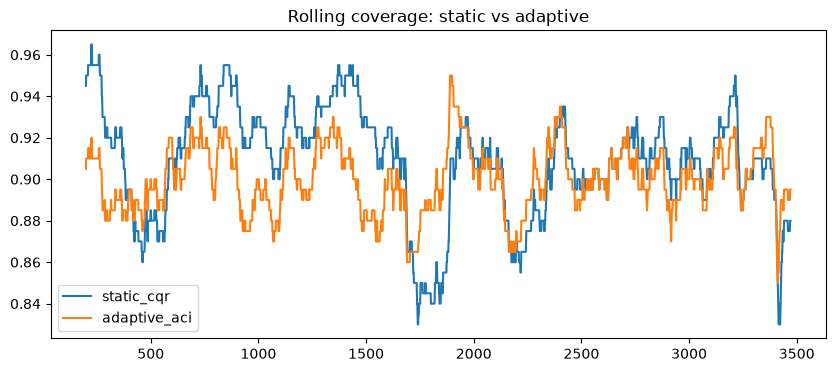

In [9]:
window = 200
static_covered = ((y_test >= cqr_lower) & (y_test <= cqr_upper)).astype(int)
static_rolling = pd.Series(static_covered).rolling(window).mean()
adaptive_rolling = pd.Series(picp_history).rolling(window).mean()

comparison = pd.DataFrame({"static_cqr": static_rolling, "adaptive_aci": adaptive_rolling})
comparison.plot(figsize=(10, 4), title="Rolling coverage: static vs adaptive")

In [10]:
def winkler_score(y_true, lower, upper, alpha):
    width = upper - lower
    score = width.copy()
    below = y_true < lower
    above = y_true > upper
    score[below] = score[below] + (2 / alpha) * (lower[below] - y_true[below])
    score[above] = score[above] + (2 / alpha) * (y_true[above] - upper[above])
    return score.mean()


# expanding window walk forward backtest, compares naive vs static vs adaptive
# across all 3 horizons, 5 folds each
all_horizon_results = []

for h in [1, 6, 24]:
    full_h = add_targets(feat_df, [h])
    full_h = full_h.reset_index(drop=True)

    total_rows = len(full_h)
    initial_train_size = int(total_rows * 0.4)
    cal_size = int(total_rows * 0.1)
    test_size = int(total_rows * 0.08)
    n_folds = 5

    for fold in range(n_folds):
        train_end = initial_train_size + fold * test_size
        cal_end = train_end + cal_size
        test_end = cal_end + test_size
        if test_end > total_rows:
            break

        train_fold = full_h.iloc[0:train_end]
        cal_fold = full_h.iloc[train_end:cal_end]
        test_fold = full_h.iloc[cal_end:test_end]

        X_train = train_fold[feature_cols]
        y_train = train_fold["target_h" + str(h)]

        lm = lgb.LGBMRegressor(objective="quantile", alpha=0.05, n_estimators=300,
                                learning_rate=0.05, max_depth=6, verbosity=-1)
        um = lgb.LGBMRegressor(objective="quantile", alpha=0.95, n_estimators=300,
                                learning_rate=0.05, max_depth=6, verbosity=-1)
        lm.fit(X_train, y_train)
        um.fit(X_train, y_train)

        X_cal = cal_fold[feature_cols]
        y_cal = cal_fold["target_h" + str(h)].values
        cal_lo = lm.predict(X_cal)
        cal_hi = um.predict(X_cal)
        fold_scores = np.maximum(cal_lo - y_cal, y_cal - cal_hi)
        n_cal = len(fold_scores)
        level = min(1.0, np.ceil((n_cal + 1) * (1 - alpha)) / n_cal)
        fold_q_hat = np.quantile(fold_scores, level)

        X_test_f = test_fold[feature_cols]
        y_test_f = test_fold["target_h" + str(h)].values
        t_lo = lm.predict(X_test_f)
        t_hi = um.predict(X_test_f)

        naive_cov = ((y_test_f >= t_lo) & (y_test_f <= t_hi)).mean()
        naive_wink = winkler_score(y_test_f, t_lo, t_hi, alpha)

        cqr_lo = t_lo - fold_q_hat
        cqr_hi = t_hi + fold_q_hat
        cqr_cov = ((y_test_f >= cqr_lo) & (y_test_f <= cqr_hi)).mean()
        cqr_wink = winkler_score(y_test_f, cqr_lo, cqr_hi, alpha)

        a_t = alpha
        a_lo = np.zeros(len(y_test_f))
        a_hi = np.zeros(len(y_test_f))
        picp = []
        for i in range(len(y_test_f)):
            qh = np.quantile(fold_scores, min(1.0, np.ceil((n_cal + 1) * (1 - a_t)) / n_cal))
            a_lo[i] = t_lo[i] - qh
            a_hi[i] = t_hi[i] + qh
            cov_i = (y_test_f[i] >= a_lo[i]) and (y_test_f[i] <= a_hi[i])
            picp.append(1 if cov_i else 0)
            err = 0 if cov_i else 1
            a_t = min(max(a_t + gamma * (alpha - err), 0.001), 0.5)

        aci_cov = np.mean(picp)
        aci_wink = winkler_score(y_test_f, a_lo, a_hi, alpha)

        all_horizon_results.append({
            "horizon": h, "fold": fold,
            "naive_coverage": naive_cov, "naive_winkler": naive_wink,
            "static_cqr_coverage": cqr_cov, "static_cqr_winkler": cqr_wink,
            "adaptive_aci_coverage": aci_cov, "adaptive_aci_winkler": aci_wink,
        })

    print("horizon", h, "done")

horizon 1 done
horizon 6 done
horizon 24 done


In [11]:
all_results_df = pd.DataFrame(all_horizon_results)
summary = all_results_df.groupby("horizon")[
    ["naive_coverage", "static_cqr_coverage", "adaptive_aci_coverage",
     "naive_winkler", "static_cqr_winkler", "adaptive_aci_winkler"]
].mean()
print(summary)

         naive_coverage  static_cqr_coverage  adaptive_aci_coverage  \
horizon                                                               
1              0.823319             0.887983               0.898999   
6              0.772799             0.894202               0.899356   
24             0.713754             0.881089               0.899140   

         naive_winkler  static_cqr_winkler  adaptive_aci_winkler  
horizon                                                           
1             0.010532            0.010226              0.010068  
6             0.022745            0.020864              0.019679  
24            0.044064            0.037913              0.032024  


In [12]:
import joblib
import json

for h in [1, 6, 24]:
    joblib.dump(models[(0.05, h)], f"lower_model_h{h}.pkl")
    joblib.dump(models[(0.95, h)], f"upper_model_h{h}.pkl")

    X_cal_h = cal_h[feature_cols]
    y_cal_h = cal_h["target_h" + str(h)].values
    cal_lo_h = models[(0.05, h)].predict(X_cal_h)
    cal_hi_h = models[(0.95, h)].predict(X_cal_h)
    scores_h = np.maximum(cal_lo_h - y_cal_h, y_cal_h - cal_hi_h)
    np.save(f"calibration_scores_h{h}.npy", scores_h)

with open("feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

print("saved models and calibration scores for all horizons")

saved models and calibration scores for all horizons


In [13]:
import requests

url = "http://127.0.0.1:8000"
h = 1

X_test = test_h[feature_cols]
y_test = test_h["target_h" + str(h)].values

n_before = 300   # normal data, establish a baseline
n_shock = 100    # fake regime shift, values pushed way outside normal range
n_after = 300    # back to normal, watch it recover

coverage_over_time = []

def send_point(i, actual_value):
    row = X_test.iloc[i % len(X_test)]
    features = {col: float(row[col]) for col in feature_cols}
    request_id = f"shock_test_{i}"
    requests.post(url + "/forecast", json={"request_id": request_id, "horizon": h, "features": features})
    result = requests.post(url + "/actual", json={"request_id": request_id, "actual_value": float(actual_value)})
    return result.json()


# phase 1: normal data
for i in range(n_before):
    r = send_point(i, y_test[i])
    coverage_over_time.append(r["rolling_coverage"])

# phase 2: induced shock, values 5x bigger than normal, model has never seen this
shock_multiplier = 5.0
for i in range(n_before, n_before + n_shock):
    shocked_value = y_test[i % len(y_test)] * shock_multiplier
    r = send_point(i, shocked_value)
    coverage_over_time.append(r["rolling_coverage"])

# phase 3: back to normal data, does it recover?
for i in range(n_before + n_shock, n_before + n_shock + n_after):
    r = send_point(i, y_test[i % len(y_test)])
    coverage_over_time.append(r["rolling_coverage"])

print("done, sent", len(coverage_over_time), "points")

done, sent 700 points


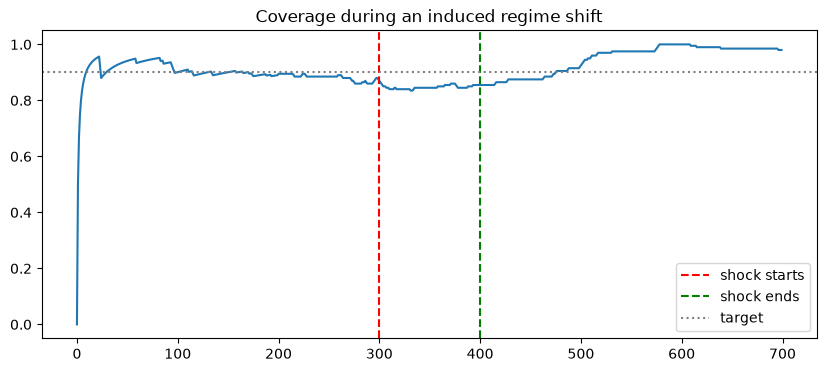

In [14]:
import pandas as pd

plot_series = pd.Series(coverage_over_time)
ax = plot_series.plot(figsize=(10, 4), title="Coverage during an induced regime shift")
ax.axvline(n_before, color="red", linestyle="--", label="shock starts")
ax.axvline(n_before + n_shock, color="green", linestyle="--", label="shock ends")
ax.axhline(0.90, color="gray", linestyle=":", label="target")
ax.legend()